Task 1 : Data loading and eploration

import  libraries

In [7]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load dataset and display 10 row of data.

In [8]:
df= pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes
5,10850000,7500,3,3,1,yes,no,yes,no,yes
6,10150000,8580,4,3,4,yes,no,no,no,yes
7,10150000,16200,5,3,2,yes,no,no,no,no
8,9870000,8100,4,1,2,yes,yes,yes,no,yes
9,9800000,5750,3,2,4,yes,yes,no,no,yes


Display total row and column is this data

In [9]:
print("Rows and column")
df.shape

Rows and column


(545, 10)

Checking all the columns 

In [10]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning'],
      dtype='str')

Display there [1] means second row data only

In [11]:
df.loc[1]

price              12250000
area                   8960
bedrooms                  4
bathrooms                 4
stories                   4
mainroad                yes
guestroom                no
basement                 no
hotwaterheating          no
airconditioning         yes
Name: 1, dtype: object

In the dataframe check in the columns null values

In [12]:
df.isnull().sum()

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
dtype: int64

checking how many duplicated value in this data

In [13]:
df.duplicated().sum()

np.int64(0)

Display overall information of data

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   mainroad         545 non-null    str  
 6   guestroom        545 non-null    str  
 7   basement         545 non-null    str  
 8   hotwaterheating  545 non-null    str  
 9   airconditioning  545 non-null    str  
dtypes: int64(5), str(5)
memory usage: 42.7 KB


TASK 2 : DATA CLEANING

Because there is no missing values then there are not requied imputation.
In there categorical variables encoding yes,no values into numerical value for training model.

In [15]:
df = pd.get_dummies(df, drop_first=True)

Check data converted in true, false 

In [16]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes
0,13300000,7420,4,2,3,True,False,False,False,True
1,12250000,8960,4,4,4,True,False,False,False,True
2,12250000,9960,3,2,2,True,False,True,False,False
3,12215000,7500,4,2,2,True,False,True,False,True
4,11410000,7420,4,1,2,True,True,True,False,True


TASK 3 : FEATURE SELECTION
Now there defining the features and aim of the overall dataset X is feature(all the column add and drop )
TARGET VARIABLE IS price.


In [17]:
X = df.drop("price", axis=1)
y = df["price"]

In [18]:
X= X.astype(int)

Training and Testing phase

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training linearRegression 

In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred_lr = lr.predict(X_test)

Linear regression results


In [22]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("MAE:" , mae)
print("MSE", rmse)
print("R2 Score",r2)

MAE: 1029305.7135858472
MSE 1413204.618503116
R2 Score 0.6048828690833075


RandomForest training

In [23]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred_rf = rf.predict(X_test)

Result of randomforest classifier now compare btw linear regression (model comparison).
Linear regression  performed well as compare to random forest then that's final model

In [25]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:",mae_rf)
print("RMSE:",rmse_rf)
print("R2:", r2_rf)


MAE: 1234830.8256880734
RMSE: 1759874.8640188894
R2: 0.38725561500781247


TASK 4: DATA VISUALIZATION

CHART 1 : HOUSE PRICE PREDICTION
using histplot

Observation : Most houses are concentrated in the medium price range.

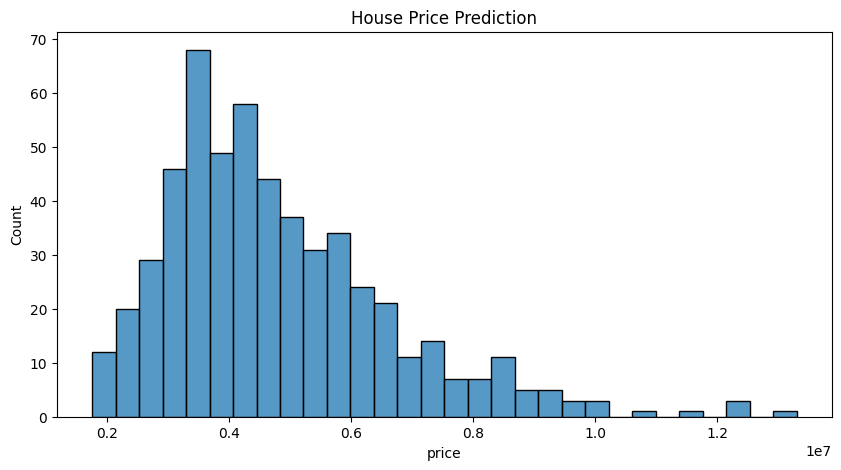

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df["price"],bins = 30)
plt.title("House Price Prediction")
plt.savefig("charts/chart1.png")
plt.show()

Now using heatmap  observed area shows the strongest positive correlation with house price

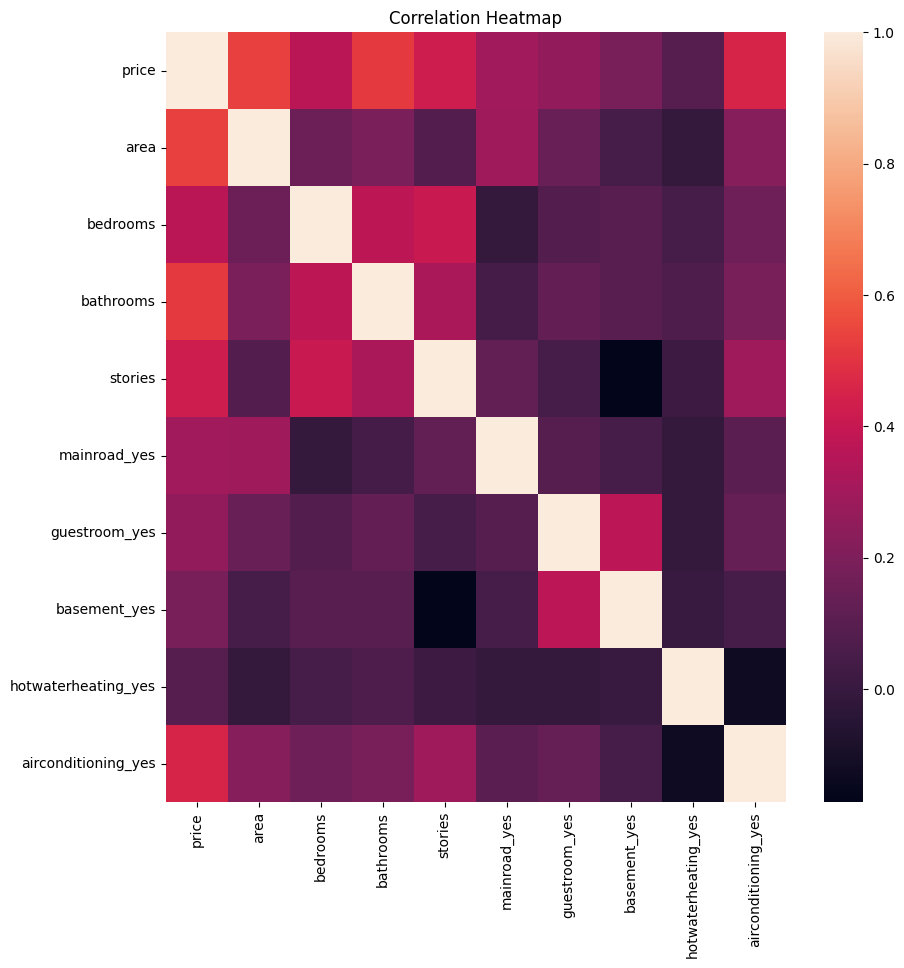

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.savefig("charts/chart2.png")
plt.show()

There is the graph of actual value vs predict values comparison Most predictions follow the actual price trend, indicating reasonable model performance.

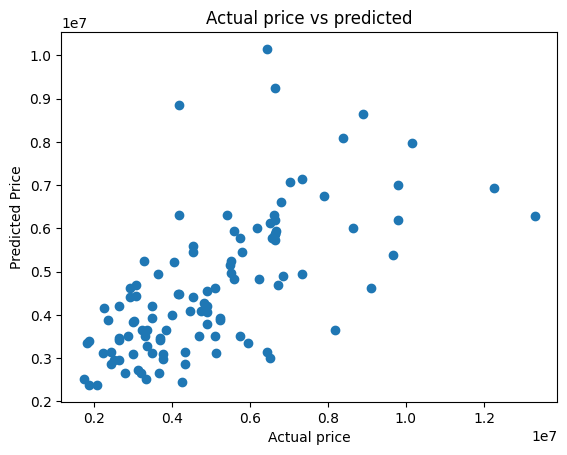

In [28]:
plt.Figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual price")
plt.ylabel("Predicted Price")
plt.title("Actual price vs predicted")
plt.savefig("charts/charts3.png")
plt.show()

Display importance value of all the features, Area is most important factor.

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending = False
).head(10)

,Feature,Importance
0,area,0.572145
1,bedrooms,0.105747
3,stories,0.095434
2,bathrooms,0.051870
8,airconditioning_yes,0.047278
6,basement_yes,0.043036
5,guestroom_yes,0.036602
4,mainroad_yes,0.024377
7,hotwaterheating_yes,0.023512


Type of class

In [30]:
print(type(X_train))
print(type(y_train))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [31]:
print(X_train.shape)
print(y_train.shape)

(436, 9)
(436,)


In [32]:
print(LinearRegression)

<class 'sklearn.linear_model._base.LinearRegression'>


In [33]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes
0,13300000,7420,4,2,3,True,False,False,False,True
1,12250000,8960,4,4,4,True,False,False,False,True
2,12250000,9960,3,2,2,True,False,True,False,False
3,12215000,7500,4,2,2,True,False,True,False,True
4,11410000,7420,4,1,2,True,True,True,False,True


Display feature importance by graph

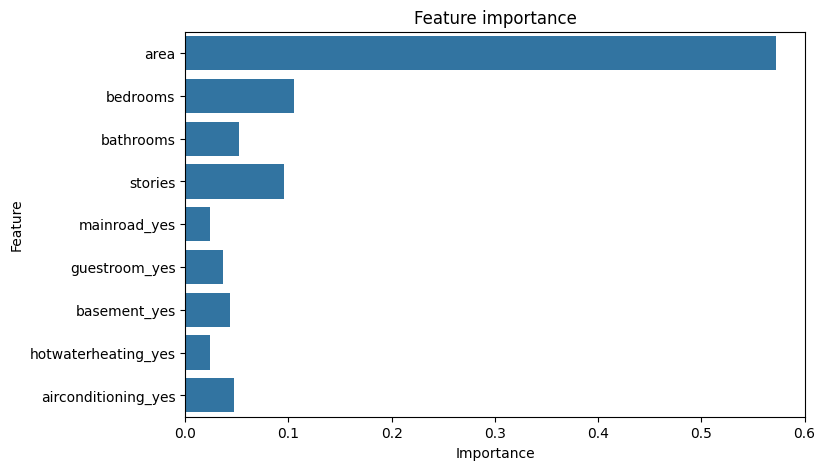

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=importance["Importance"],
    y=importance["Feature"]
)
plt.title("Feature importance")
plt.savefig("charts/chart4.png")
plt.show()

Classified price in categories Low, Medium, High

In [35]:
df["price_categories"] = pd.cut(
    df["price"],
    bins=3,
    labels=["low","medium","High"]
)
print(df["price_categories"].value_counts())

price_categories
low       403
medium    130
High       12
Name: count, dtype: int64


There is showing Outliers of house price in boxplot.

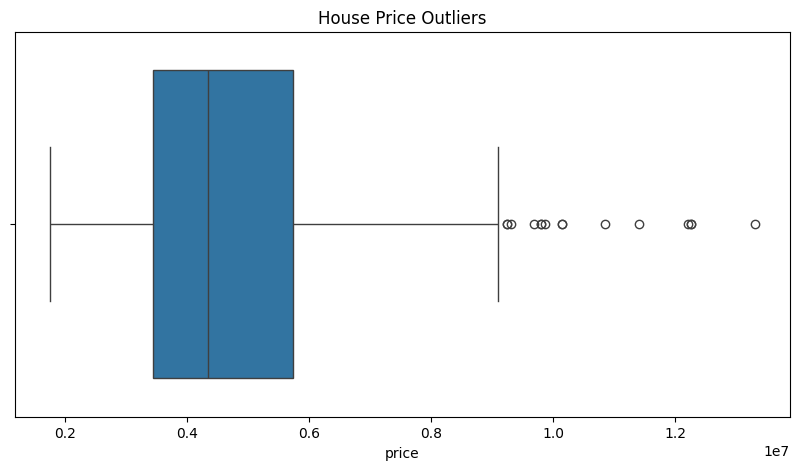

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["price"])
plt.title("House Price Outliers")
plt.show()
plt.savefig("charts/charts5.png")


There is displayed predict error distribution by bins shows in histogram.


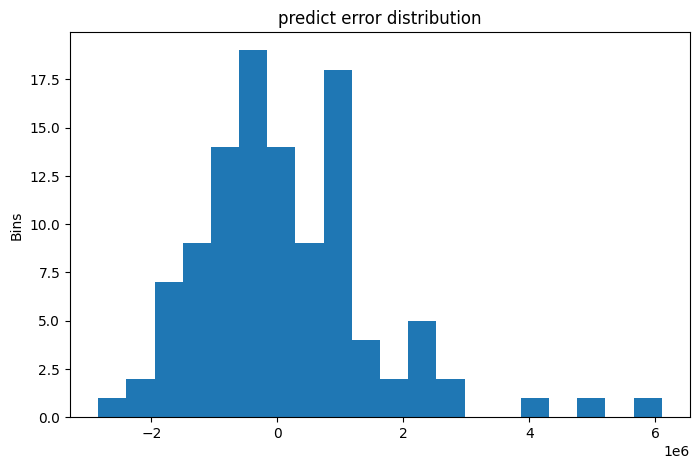

In [37]:
errors = y_test - y_pred_lr
plt.figure(figsize=(8,5))
plt.hist(errors,bins=20)
plt.title("predict error distribution")
plt.ylabel("Bins")
plt.show()

Correlation between features with sorting in descending order.

In [38]:
corr = df.corr(numeric_only=True)["price"]
print(corr.sort_values(ascending=False))

price                  1.000000
area                   0.535997
bathrooms              0.517545
airconditioning_yes    0.452954
stories                0.420712
bedrooms               0.366494
mainroad_yes           0.296898
guestroom_yes          0.255517
basement_yes           0.187057
hotwaterheating_yes    0.093073
Name: price, dtype: float64


Making new column total rooms

In [39]:
df["total_rooms"]= df["bathrooms"] + df["bedrooms"]

In [40]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,price_categories,total_rooms
0,13300000,7420,4,2,3,True,False,False,False,True,High,6
1,12250000,8960,4,4,4,True,False,False,False,True,High,8
2,12250000,9960,3,2,2,True,False,True,False,False,High,5
3,12215000,7500,4,2,2,True,False,True,False,True,High,6
4,11410000,7420,4,1,2,True,True,True,False,True,High,5
5,10850000,7500,3,3,1,True,False,True,False,True,High,6
6,10150000,8580,4,3,4,True,False,False,False,True,High,7
7,10150000,16200,5,3,2,True,False,False,False,False,High,8
8,9870000,8100,4,1,2,True,True,True,False,True,High,5
9,9800000,5750,3,2,4,True,True,False,False,True,High,5


In [41]:
df["bathroom_bedroom_ratio"] = (
    df["bathrooms"] / df["bedrooms"]
)

In [42]:
from sklearn.model_selection import cross_val_score
scores= cross_val_score(
    lr,
    X,
    y,
    cv=5,
    scoring="r2"
)
print(scores)
print(scores.mean())

[ -2.23011292  -4.73209155 -18.2899806  -19.54715221  -7.1865769 ]
-10.397182834892252


In [43]:
from sklearn.model_selection import learning_curve

Sample house price prediction

In [ ]:
sample_house = [[6000,3,2,2,1,0,0,0,1]]

prediction = lr.predict(sample_house)
print("Predicted Price",prediction)

Predicted Price [6275582.25227182]


c:\Users\Shivam\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Taking the User input then Predict house price.

In [70]:
area = int(input("Enter Area: "))
bedrooms = int(input("Enter Bedrooms: "))
bathrooms = int(input("Enter Bathrooms: "))
stories = int(input("Enter Stories: "))

mainroad = int(input("Main Road (1=Yes, 0=No): "))
guestroom = int(input("Guest Room (1=Yes, 0=No): "))
basement = int(input("Basement (1=Yes, 0=No): "))
hotwaterheating = int(input("Hot Water Heating (1=Yes, 0=No): "))
airconditioning = int(input("Air Conditioning (1=Yes, 0=No): "))

print("\n===== House Details =====")
print("Area:", area)
print("Bedrooms:", bedrooms)
print("Bathrooms:", bathrooms)
print("Stories:", stories)
print("Main Road:", mainroad)
print("Guest Room:", guestroom)
print("Basement:", basement)
print("Hot Water Heating:", hotwaterheating)
print("Air Conditioning:", airconditioning)


===== House Details =====
Area: 10000
Bedrooms: 8
Bathrooms: 5
Stories: 6
Main Road: 1
Guest Room: 0
Basement: 1
Hot Water Heating: 0
Air Conditioning: 1


In [73]:
sample_house = pd.DataFrame({
    'area':[area],
    'bedrooms':[bedrooms],
    'bathrooms':[bathrooms],
    'stories':[stories],
    'mainroad_yes':[mainroad],
    'guestroom_yes':[guestroom],
    'basement_yes':[basement],
    'hotwaterheating_yes':[hotwaterheating],
    'airconditioning_yes':[airconditioning]
})

In [74]:
prediction = lr.predict(sample_house)

display(sample_house)

print(f"\nPredicted House Price: ₹{prediction[0]:,.2f}")

,area,bedrooms,bathrooms,stories,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes
0,10000,8,5,6,1,0,1,0,1



Predicted House Price: ₹13,499,630.31
